In [16]:
!pip install scrapy crochet -q

import scrapy
from scrapy.crawler import CrawlerRunner
import pandas as pd
from crochet import setup, wait_for

setup()

scraped_books = []
class BooksSpider(scrapy.Spider):
    name = "books_spider"
    allowed_domains = ["books.toscrape.com"]
    start_urls = ["https://books.toscrape.com/catalogue/page-1.html"]
    page_count = 1
    max_pages = 5
    custom_settings = {
        'LOG_LEVEL': 'ERROR',
        'CONCURRENT_REQUESTS': 8,
        'DOWNLOAD_DELAY': 0.1,
        'TWISTED_REACTOR': 'twisted.internet.epollreactor.EPollReactor'
    }

    def parse(self, response):
        book_links = response.css("article.product_pod h3 a::attr(href)").getall()
        for link in book_links:
            yield response.follow(link, callback=self.parse_book)
        self.page_count += 1
        if self.page_count <= self.max_pages:
            next_page = response.css("li.next a::attr(href)").get()
            if next_page:
                yield response.follow(next_page, callback=self.parse)
    def parse_book(self, response):
        title = response.css("div.product_main h1::text").get("").strip()
        category = response.css("ul.breadcrumb li:nth-child(3) a::text").get("").strip()
        price = response.css("p.price_color::text").get("").strip()
        rating_classes = response.css("p.star-rating::attr(class)").get("").split()
        rating = rating_classes[1] if len(rating_classes) > 1 else ""
        availability = " ".join(response.css("p.availability::text").getall()).strip()
        description = response.css("div#product_description + p::text").get("").strip()

        table_rows = response.css("table.table-striped tr")
        product_info = {}
        for row in table_rows:
            key = row.css("th::text").get("").strip()
            val = row.css("td::text").get("").strip()
            product_info[key] = val

        book_item = {
            "Title": title,
            "Category": category,
            "Price": price,
            "Rating": rating,
            "Availability": availability,
            "Product Description": description,
            "UPC": product_info.get("UPC", ""),
            "Number of Reviews": product_info.get("Number of reviews", ""),
            "Product URL": response.url
        }

        scraped_books.append(book_item)
        yield book_item

@wait_for(timeout=60.0)
def run_spider():
    scraped_books.clear()
    runner = CrawlerRunner()
    return runner.crawl(BooksSpider)
run_spider()


df = pd.DataFrame(scraped_books)
df.to_csv("books_100.csv", index=False, encoding="utf-8")
df.to_json("books_100.json", orient="records", indent=4)
print("\n========== SCRAPING SUMMARY ==========")
print("Total Books Scraped :", len(df))
print("Pages Scraped       : 5")
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate UPC Values :", df["UPC"].duplicated().sum() if "UPC" in df else 0)
print("\nFiles Generated:")
print("1. books_100.csv")
print("2. books_100.json")


========== SCRAPING SUMMARY ==========
Total Books Scraped : 100
Pages Scraped       : 5

Missing Values:
Title                  0
Category               0
Price                  0
Rating                 0
Availability           0
Product Description    0
UPC                    0
Number of Reviews      0
Product URL            0
dtype: int64

Duplicate UPC Values : 0

Files Generated:
1. books_100.csv
2. books_100.json


In [13]:
!pip install wordcloud matplotlib seaborn pandas -q

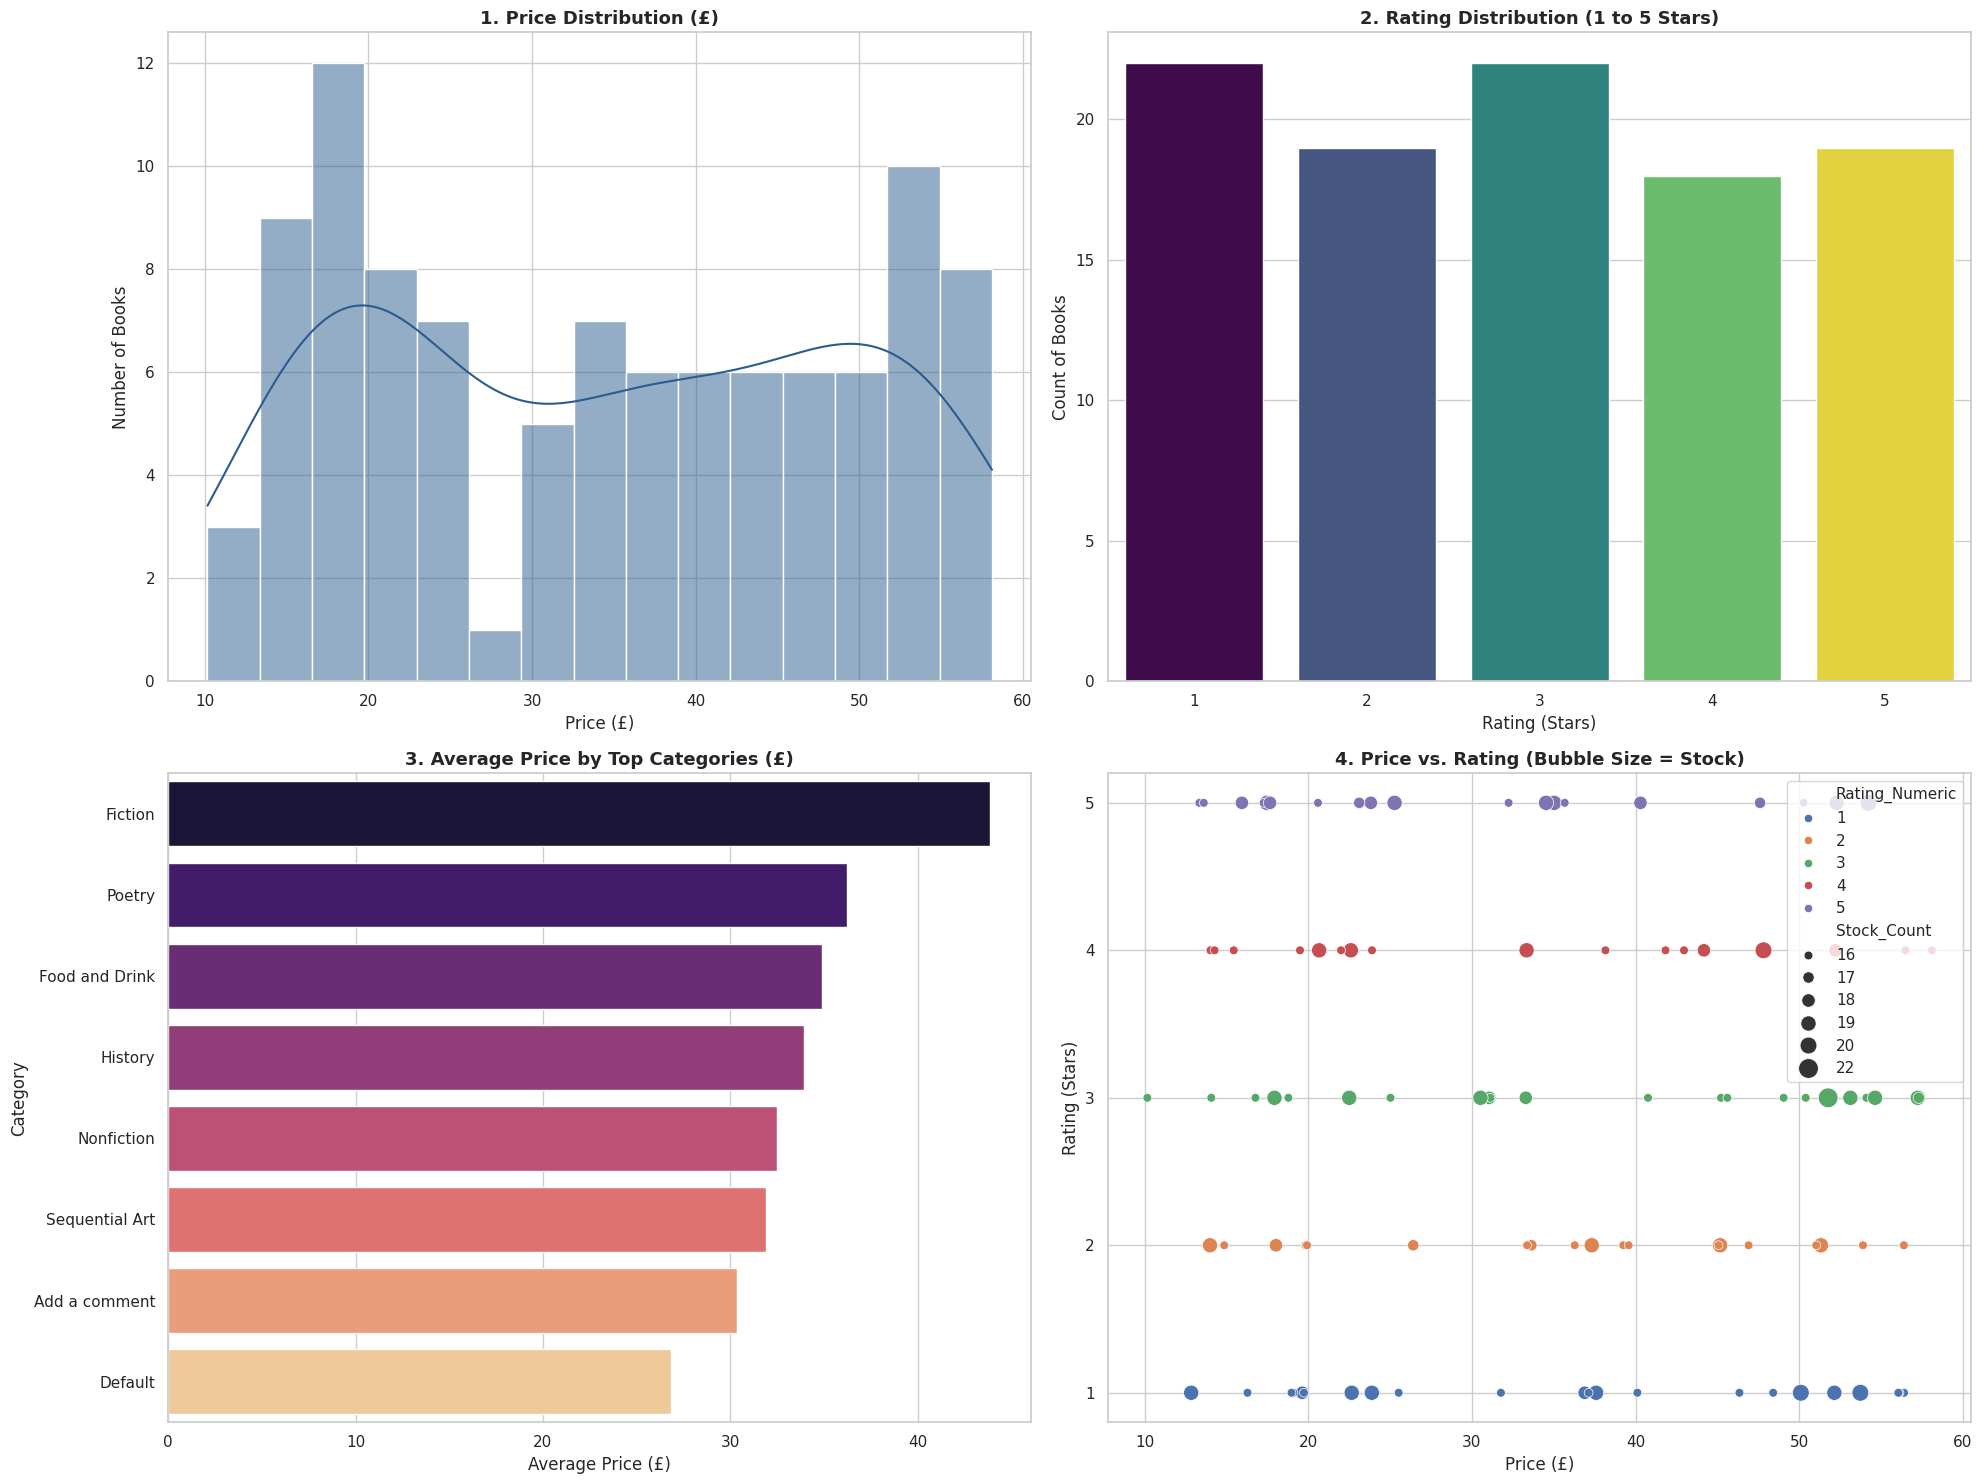

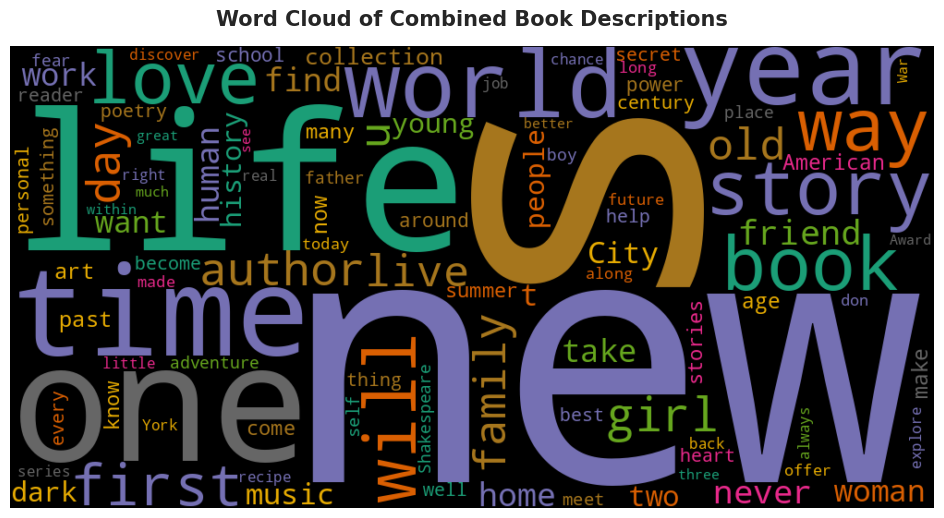

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_theme(style="whitegrid")
df = pd.read_csv("books_100_cleaned.csv")
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# PLOT 1: Price Distribution (Histogram with KDE)
sns.histplot(
    data=df,
    x="Price_Numeric",
    kde=True,
    color="#2b5c8f",
    bins=15,
    ax=axes[0, 0]
)
axes[0, 0].set_title("1. Price Distribution (£)", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Price (£)")
axes[0, 0].set_ylabel("Number of Books")

# PLOT 2: Rating Distribution (Count Bar Plot)
sns.countplot(
    data=df,
    x="Rating_Numeric",
    hue="Rating_Numeric",
    palette="viridis",
    legend=False,
    ax=axes[0, 1]
)
axes[0, 1].set_title("2. Rating Distribution (1 to 5 Stars)", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("Rating (Stars)")
axes[0, 1].set_ylabel("Count of Books")

# PLOT 3: Average Price by Category (Top Categories)
top_cats = df["Category"].value_counts().head(8).index
cat_df = df[df["Category"].isin(top_cats)].groupby("Category")["Price_Numeric"].mean().reset_index()
cat_df = cat_df.sort_values(by="Price_Numeric", ascending=False)
sns.barplot(
    data=cat_df,
    x="Price_Numeric",
    y="Category",
    hue="Category",
    palette="magma",
    legend=False,
    ax=axes[1, 0]
)
axes[1, 0].set_title("3. Average Price by Top Categories (£)", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Average Price (£)")
axes[1, 0].set_ylabel("Category")

# PLOT 4: Relationship Plot (Price vs. Rating with Stock size)
sns.scatterplot(
    data=df,
    x="Price_Numeric",
    y="Rating_Numeric",
    hue="Rating_Numeric",
    size="Stock_Count",
    sizes=(40, 200),
    palette="deep",
    ax=axes[1, 1]
)
axes[1, 1].set_title("4. Price vs. Rating (Bubble Size = Stock)", fontsize=13, fontweight="bold")
axes[1, 1].set_xlabel("Price (£)")
axes[1, 1].set_ylabel("Rating (Stars)")
axes[1, 1].set_yticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

# WORD CLOUD GENERATION
descriptions_text = " ".join(
    desc for desc in df["Product Description"] if desc != "No description available"
)

# Generate WordCloud object
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="black",
    max_words=100,
    colormap="Dark2",
    collocations=False
).generate(descriptions_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Combined Book Descriptions", fontsize=15, fontweight="bold", pad=15)
plt.show()